# Purpose
Evaluate text encoders in isolation to decide which ones are worth pairing with vision encoders later.

# Imports

In [9]:
import os, gc, json, pickle
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    AutoModel, CLIPTextModel
)

import quantus
from captum.attr import IntegratedGradients, Saliency
from scipy.stats import spearmanr
import torch.nn.functional as F


/home/aysel/tfe/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [10]:
CURRENT_DATASET = "Flickr8k"
BASE_DIR = "TFE_Data"
DATASETS_DIR = os.path.join(BASE_DIR, "Datasets")

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print("Using device:", device)


Using device: cuda


In [11]:
# Data Loader
class TextDataset(torch.utils.data.Dataset):
    def __init__(self, texts, tokenizer, max_len=64):
        self.texts = texts
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )
        return enc


# Load Models

In [12]:
class TextWrapper(nn.Module):
    def __init__(self, backbone, head):
        super().__init__()
        self.backbone = backbone
        self.head = head

    def forward(self, input_ids, attention_mask=None):
        out = self.backbone(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_hidden_states=True,
            return_dict=True
        )
        cls = out.last_hidden_state[:, 0, :]
        return self.head(cls)

    def get_input_embeddings(self):
        return self.backbone.get_input_embeddings()


In [13]:
def load_bert(device):
    tok = AutoTokenizer.from_pretrained("bert-base-uncased")
    model = AutoModelForSequenceClassification.from_pretrained(
        "bert-base-uncased",
        num_labels=2
    ).to(device).eval()
    backbone = model.bert
    return model, tok, backbone


def load_roberta(device):
    tok = AutoTokenizer.from_pretrained("roberta-base")
    model = AutoModelForSequenceClassification.from_pretrained(
        "roberta-base",
        num_labels=2
    ).to(device).eval()
    return model, tok, model.roberta

def load_gpt2(device):
    tok = AutoTokenizer.from_pretrained("gpt2")
    tok.pad_token = tok.eos_token  # OBLIGATOIRE
    model = AutoModelForSequenceClassification.from_pretrained(
        "gpt2",
        num_labels=2,
        pad_token_id=tok.pad_token_id  # OBLIGATOIRE
    ).to(device).eval()
    return model, tok, model.transformer


def load_clip_text(device):
    tok = AutoTokenizer.from_pretrained("openai/clip-vit-base-patch32")
    tok.pad_token = tok.eos_token  # indispensable

    backbone = CLIPTextModel.from_pretrained("openai/clip-vit-base-patch32")
    head = nn.Linear(backbone.config.hidden_size, 2)

    model = TextWrapper(backbone, head).to(device).eval()
    return model, tok, backbone


# Captum Attributions

In [14]:
class EmbeddingWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
        self.embeddings = model.get_input_embeddings()

    def forward(self, embeddings, attention_mask=None):
        outputs = self.model(
            inputs_embeds=embeddings,
            attention_mask=attention_mask
        )
        return outputs.logits if hasattr(outputs, "logits") else outputs



In [15]:
class CLIPIGWrapper(nn.Module):
    def __init__(self, backbone, head):
        super().__init__()
        self.backbone = backbone
        self.head = head

    def forward(self, embeddings, attention_mask=None):
        out = self.backbone(
            inputs_embeds=embeddings,
            attention_mask=attention_mask,
            output_hidden_states=True,
            return_dict=True
        )
        cls = out.last_hidden_state[:, 0, :]
        return self.head(cls)


In [16]:
def explain_ig(model, batch, target):
    emb_layer = model.get_input_embeddings()
    input_embeds = emb_layer(batch["input_ids"])

    # Si modèle = CLIP-Text → wrapper IG spécial
    if isinstance(model, TextWrapper):
        wrapper = CLIPIGWrapper(model.backbone, model.head)
    else:
        wrapper = EmbeddingWrapper(model)

    ig = IntegratedGradients(wrapper)

    attributions = ig.attribute(
        input_embeds,
        additional_forward_args=(batch["attention_mask"],),
        target=target
    )

    return attributions.norm(dim=-1)


In [17]:
def explain_saliency(model, batch, target):

    emb_layer = model.get_input_embeddings()

    # token embeddings
    input_embeds = emb_layer(batch["input_ids"])

    # wrapper using inputs_embeds
    wrapper = EmbeddingWrapper(model)

    sal = Saliency(wrapper)

    attributions = sal.attribute(
        input_embeds,
        additional_forward_args=(batch["attention_mask"],),
        target=target
    )

    # token-level importance
    return attributions.norm(dim=-1)

In [18]:
models_text = {
    "BERT": load_bert(device),
    "RoBERTa": load_roberta(device),
    "GPT-2": load_gpt2(device),
}

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] GPT2ForSequenceClassification LOAD REPORT from: gpt2
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


# Captum Generate Explanations

In [57]:
df_text = pd.read_pickle(os.path.join(DATASETS_DIR, "df_Flickr8k.pkl"))

# IMPORTANT: Flickr8k has 5 captions per image → we take only the first
TEXTS = [caps[0] for caps in df_text["captions"].tolist()]
TEXTS = TEXTS[:50]

# ============================================================
# BUILD STRESS TEST CAPTION SET
# ============================================================

stress_test_text = []

IMAGE_DIR = os.path.join(BASE_DIR, "Flickr8k", "Images", "Flicker8k_Dataset")

STRESS_TEST_IMAGES = [
    "107582366_d86f2d3347.jpg",
    "127450902_533ceeddfc.jpg",
    "112178718_87270d9b4d.jpg",
    "141755290_4b954529f3.jpg",
    "171488318_fb26af58e2.jpg",
    "240583223_e26e17ee96.jpg",
    "241346317_be3f07bd2e.jpg",
    "911795495_342bb15b97.jpg",
    "2452686995_621878f561.jpg",
    "97577988_65e2eae14a.jpg"
]

# ------------------------------------------------------------
# KEEP ONLY STRESS TEST IMAGES
# ------------------------------------------------------------

df_stress = df_text[
    df_text["image_name"].isin(STRESS_TEST_IMAGES)
].reset_index(drop=True)

# ------------------------------------------------------------
# BUILD CAPTION LIST
# ------------------------------------------------------------

captions = []
caption_image_map = []

for _, row in df_stress.iterrows():

    image_name = row["image_name"]

    for cap in row["captions"]:

        captions.append(cap)
        caption_image_map.append(image_name)

print("Captions:", len(captions))

Captions: 50


In [ ]:
all_attrs_text = []

for name, (model, tok, backbone) in models_text.items():

    print(f"\n=== Running {name} ===")

    dataset = TextDataset(TEXTS, tok)
    loader = torch.utils.data.DataLoader(dataset, batch_size=1)

    model_attrs = []

    for idx, batch in enumerate(loader):

        batch = {
            "input_ids": batch["input_ids"].squeeze(0).long().to(device),
            "attention_mask": batch["attention_mask"].squeeze(0).long().to(device)
        }

        out = model(
            batch["input_ids"],
            attention_mask=batch["attention_mask"]
        )

        logits = out.logits if hasattr(out, "logits") else out

        label = logits.argmax(dim=1).item()

        # ----------------------------------------------------
        # EXPLANATIONS
        # ----------------------------------------------------

        ig_attr = explain_ig(model, batch, label)

        sal_attr = explain_saliency(model, batch, label)

        # ----------------------------------------------------
        # SAVE
        # ----------------------------------------------------

        model_attrs.append({
            "text_idx": idx,
            "label": label,
            "IG": ig_attr.cpu(),
            "Saliency": sal_attr.cpu(),
            "input_ids": batch["input_ids"].cpu(),
        })

    all_attrs_text.append({
        "model": name,
        "attrs": model_attrs
    })

# SAVE
with open("captum_text.pkl", "wb") as f:
    pickle.dump(all_attrs_text, f)

print("Saved successfully.")


=== Running BERT ===

=== Running RoBERTa ===


[transformers] GPT2ForSequenceClassification will not detect padding tokens in `inputs_embeds`. Results may be unexpected if using padding tokens in conjunction with `inputs_embeds.`



=== Running GPT-2 ===
Saved successfully.


In [ ]:
for k in models_text:
    model, tok, backbone = models_text[k]
    model.to(device).eval()

for name, (model, tok, backbone) in models_text.items():

    print(f"\n=== Running {name} ===")

    dataset = TextDataset(captions, tok)
    loader = torch.utils.data.DataLoader(dataset, batch_size=1)

    model_attrs = []

    for idx, batch in enumerate(loader):
        model = model.to(device).eval()

        batch = {
            "input_ids": batch["input_ids"].squeeze(0).long().to(device),
            "attention_mask": batch["attention_mask"].squeeze(0).long().to(device)
        }

        out = model(
            batch["input_ids"],
            attention_mask=batch["attention_mask"]
        )

        logits = out.logits if hasattr(out, "logits") else out

        label = logits.argmax(dim=1).item()

        # ----------------------------------------------------
        # EXPLANATIONS
        # ----------------------------------------------------

        ig_attr = explain_ig(model, batch, label)
        sal_attr = explain_saliency(model, batch, label)

        # ----------------------------------------------------
        # SAVE
        # ----------------------------------------------------

        model_attrs.append({
            "text_idx": idx,
            "image_name": caption_image_map[idx],
            "caption": captions[idx],
            "label": label,
            "IG": ig_attr.cpu(),
            "Saliency": sal_attr.cpu(),
            "input_ids": batch["input_ids"].cpu(),
        })

    stress_test_text.append({
        "model": name,
        "attrs": model_attrs
    })

with open("captum_text_stress_test.pkl", "wb") as f:
    pickle.dump(stress_test_text, f)

print("Saved successfully.")

Captions: 50

=== Running BERT ===

=== Running RoBERTa ===

=== Running GPT-2 ===
Saved successfully.


In [ ]:
def visualize_tokens(
    tokenizer,
    input_ids,
    attributions,
    title="Token Attribution"
):

    # --------------------------------------------------------
    # TOKENS
    # --------------------------------------------------------

    tokens = tokenizer.convert_ids_to_tokens(
        input_ids.squeeze().tolist()
    )

    scores = attributions.squeeze().detach().cpu().numpy()

    # --------------------------------------------------------
    # REMOVE SPECIAL TOKENS / PADDING
    # --------------------------------------------------------

    filtered_tokens = []
    filtered_scores = []

    special_tokens = set(tokenizer.all_special_tokens)

    for token, score in zip(tokens, scores):

        # skip padding + special tokens
        if token in special_tokens:
            continue

        # skip empty
        if token.strip() == "":
            continue

        filtered_tokens.append(token)
        filtered_scores.append(score)

    scores = np.array(filtered_scores)

    # --------------------------------------------------------
    # NORMALIZE
    # --------------------------------------------------------

    scores = scores / (np.max(np.abs(scores)) + 1e-8)

    # --------------------------------------------------------
    # PLOT
    # --------------------------------------------------------

    fig, ax = plt.subplots(figsize=(16, 2))

    ax.axis("off")

    x = 0.01

    for token, score in zip(filtered_tokens, scores):

        color = plt.cm.Reds(abs(score))

        ax.text(
            x,
            0.5,
            token,
            fontsize=12,
            transform=ax.transAxes,
            bbox=dict(
                facecolor=color,
                alpha=0.8,
                edgecolor="black"
            )
        )

        x += 0.04 + len(token) * 0.003

    plt.title(title)
    plt.show()

for entry in stress_test_text:

    model_name = entry["model"]

    model_key = (
        model_name.lower()
        .replace("-", "")
        .replace("_", "")
    )

    matching_key = None

    for k in models_text.keys():

        norm = k.lower().replace("-", "").replace("_", "")

        if norm == model_key:
            matching_key = k
            break

    _, tok, _ = models_text[matching_key]

    # first sample
    item = entry["attrs"][0]

    image_name = item["image_name"]

    image_path = os.path.join(
        IMAGE_DIR,
        image_name
    )

    visualize_tokens(
        tokenizer=tok,
        input_ids=item["input_ids"][0],
        attributions=item["IG"][0],
        title=f"{model_name}"
    )

TypeError: visualize_tokens() got an unexpected keyword argument 'image_path'

# Quantus Metrics Evaluate Explanations

In [2]:
def rankcorr_text(model, batch, label, attr):
    model_cpu = model.to("cpu").eval()
    ids = batch["input_ids"].clone().cpu()

    base = model_cpu(ids, attention_mask=batch["attention_mask"].cpu()).logits.softmax(1)[0, label].item()

    impacts = []
    attrs = attr.squeeze().detach().cpu().numpy()
    for i in range(len(ids[0])):
        ids_mod = ids.clone()
        ids_mod[0, i] = 0
        out = model_cpu(ids_mod, attention_mask=batch["attention_mask"].cpu()).logits.softmax(1)[0, label].item()
        impacts.append(base - out)

    corr, _ = spearmanr(attrs, impacts)
    return corr

In [28]:
def get_valid_mask_token(tok):
    if tok.mask_token_id is not None:
        return tok.mask_token_id
    # fallback for GPT‑2, CLIP, etc.
    return tok.eos_token_id


In [29]:
def rankcorr_text_masking(model, batch, label, attr, mask_token_id):
    model_cpu = model.to("cpu").eval()

    ids = batch["input_ids"].clone().cpu()
    attn = batch["attention_mask"].clone().cpu()

    seq_len = ids.shape[1]

    # ⭐ get a valid mask token
    mask_token_id = get_valid_mask_token(tok)

    # Build batch: original + masked versions
    ids_batch = ids.repeat(seq_len + 1, 1)  # (L+1, L)
    attn_batch = attn.repeat(seq_len + 1, 1)

    # Mask each token in its own row
    for i in range(seq_len):
        ids_batch[i + 1, i] = mask_token_id

    # Forward pass ONCE
    with torch.no_grad():
        logits = model_cpu(ids_batch, attention_mask=attn_batch).logits.softmax(1)

    base = logits[0, label].item()
    masked_scores = logits[1:, label].numpy()

    impacts = base - masked_scores
    attrs = attr.squeeze().detach().cpu().numpy()

    corr, _ = spearmanr(attrs, impacts)
    return corr

In [4]:
def entropy_text(attr):
    a = attr.squeeze().detach().cpu().numpy()
    a = np.abs(a)
    a = a / (a.sum() + 1e-8)
    return -np.sum(a * np.log(a + 1e-8))


In [5]:
def attention_alignment(model, backbone, batch, attr):
    with torch.no_grad():
        out = backbone(
            batch["input_ids"].cpu(),
            attention_mask=batch["attention_mask"].cpu(),
            output_attentions=True,
            return_dict=True
        )
        attn = out.attentions[-1].mean(1).mean(1).cpu().numpy()

    a = attr.squeeze().detach().cpu().numpy()
    corr, _ = spearmanr(a, attn)
    return corr


In [ ]:
def stability_text(model, batch, label, attr):
    model_cpu = model.to("cpu").eval()

    # 1. Embeddings
    emb_layer = model_cpu.get_input_embeddings()
    input_embeds = emb_layer(batch["input_ids"].cpu())

    # 2. Wrapper IG
    wrapper = EmbeddingWrapper(model_cpu)
    ig = IntegratedGradients(wrapper)

    def aug_embeds(embeds):
        embeds = embeds.clone()
        if embeds.shape[1] > 3:
            embeds[0,1] = embeds[0,2]
        return embeds

    sims = []
    for _ in range(1):
        embeds_aug = aug_embeds(input_embeds)

        attr_aug = ig.attribute(
            embeds_aug,
            additional_forward_args=(batch["attention_mask"].cpu(),),
            target=label
        )

        attr_aug = attr_aug.norm(dim=-1)

        a1 = attr.detach().cpu().numpy().flatten()
        a2 = attr_aug.detach().cpu().numpy().flatten()

        sim = np.dot(a1, a2) / (np.linalg.norm(a1)*np.linalg.norm(a2) + 1e-8)
        sims.append(sim)

    return float(np.mean(sims))


In [7]:
import time

In [ ]:
def text_to_signal(model, input_ids):
    # Ensure input_ids is on the same device as the model
    device = next(model.parameters()).device
    input_ids = input_ids.to(device)

    emb = model.get_input_embeddings()(input_ids)     # (seq_len, hidden_dim)
    signal = emb.norm(dim=-1)                         # (seq_len,)
    return signal.unsqueeze(0).detach().cpu().numpy()

def reduce_attr_for_quantus_text(attr):
    return attr.detach().cpu().numpy().reshape(1, -1)

class QuantusTextWrapper(nn.Module):
    def __init__(self, model, input_ids):
        super().__init__()
        self.model = model
        self.emb = model.get_input_embeddings()

        # Move input_ids to the same device as the model
        device = next(model.parameters()).device
        self.input_ids = input_ids.to(device)

    def forward(self, x):
        # Normalize Quantus input
        x = np.array(x).astype(np.float32).reshape(1, -1)
        x = torch.from_numpy(x).to(self.input_ids.device)

        base = self.emb(self.input_ids)               # (seq_len, hidden_dim)
        norm = base.norm(dim=-1, keepdim=True)
        unit = base / (norm + 1e-8)

        emb = unit * x.unsqueeze(-1)                  # (1, seq_len, hidden_dim)

        out = self.model(inputs_embeds=emb).logits
        return out


In [21]:
def evaluate_quantus_text(model, input_ids, label, attr):
    signal = text_to_signal(model, input_ids)
    a_np = reduce_attr_for_quantus_text(attr)
    y_np = np.array([label])

    # IMPORTANT FIX
    wrapper = QuantusTextWrapper(model, input_ids).eval()

    metrics = [
        quantus.FaithfulnessCorrelation(
            subset_size=5,
            nr_runs=10,
            similarity_func=quantus.similarity_func.correlation_spearman
        ),
        quantus.Complexity(),
        quantus.Sparseness()
    ]

    results = {}
    for m in metrics:
        print(f"doing {str(m)}")
        try:
            results[m.__class__.__name__] = m(
                model=wrapper,
                x_batch=signal,
                a_batch=a_np,
                y_batch=y_np
            )
        except Exception as e:
            print(f"[Quantus error] {m.__class__.__name__}: {e}")
            results[m.__class__.__name__] = np.nan

    return results


In [33]:
with open("captum_text.pkl", "rb") as f:
    all_attrs_text = pickle.load(f)


In [34]:
import nltk
from nltk.corpus import wordnet as wn
nltk.download("wordnet", quiet=True)

def synonym_paraphrase(tokens):
    new_tokens = []
    for tok in tokens:
        syns = wn.synsets(tok)
        if syns:
            lemmas = syns[0].lemma_names()
            if len(lemmas) > 1:
                new_tokens.append(lemmas[1].replace("_", " "))
                continue
        new_tokens.append(tok)
    return new_tokens


In [35]:
def compute_ig(model, tok, text_ids, label):
    emb_layer = model.get_input_embeddings()
    input_embeds = emb_layer(text_ids)

    wrapper = EmbeddingWrapper(model)
    ig = IntegratedGradients(wrapper)

    attr = ig.attribute(
        input_embeds,
        additional_forward_args=((text_ids != 0).long(),),
        target=label
    )
    return attr.norm(dim=-1)


In [36]:
def paraphrase_robustness(model, tok, batch, label, attr):
    # 1. Decode tokens
    tokens = tok.convert_ids_to_tokens(batch["input_ids"][0])

    # 2. Paraphrase tokens
    para_tokens = synonym_paraphrase(tokens)

    # 3. Re-tokenize paraphrased text
    para_text = tok.convert_tokens_to_string(para_tokens)
    para_ids = tok(para_text, return_tensors="pt").input_ids

    # 4. Compute IG for paraphrased text
    attr_para = compute_ig(model, tok, para_ids, label)

    # 5. Compare original vs paraphrased IG
    a1 = attr.squeeze().detach().cpu().numpy()
    a2 = attr_para.squeeze().detach().cpu().numpy()

    # Pad to same length if needed
    L = min(len(a1), len(a2))
    a1, a2 = a1[:L], a2[:L]

    # Cosine similarity = robustness
    sim = np.dot(a1, a2) / (np.linalg.norm(a1)*np.linalg.norm(a2) + 1e-8)
    return float(sim)


In [38]:

text_results = []
time_explain = {}

for entry in all_attrs_text:
    model_name = entry["model"]
    model, tok, backbone = models_text[model_name]
    print(f"Evaluating {model_name}...")
    start = time.time()
    model_scores = []

    for item in entry["attrs"]:
        print(f" doing {len(model_scores)}")
        label = item["label"]
        attr = item["IG"]
        ids = item["input_ids"]

        batch = {"input_ids": ids, "attention_mask": (ids!=0).long()}

        quantus_scores = evaluate_quantus_text(model, ids, label, attr)

        scores = {
            "ParaphraseRobustness": paraphrase_robustness(model, tok, batch, label, attr),
            **quantus_scores,
            #"RankCorrelation": rankcorr_text(model, batch, label, attr),
            "Entropy": entropy_text(attr),
            "Stability": stability_text(model, batch, label, attr),
            #"MaskRankCorr": rankcorr_text_masking(model, batch, label, attr, tok)
        }

        model_scores.append(scores)
    time_explain[model_name] = time.time() - start
    text_results.append({"model": model_name, "scores": model_scores})


Evaluating BERT...
 doing 0
doing <quantus.metrics.faithfulness.faithfulness_correlation.FaithfulnessCorrelation object at 0x7f3bc9b54f20>
doing <quantus.metrics.complexity.complexity.Complexity object at 0x7f3bc8393c80>
doing <quantus.metrics.complexity.sparseness.Sparseness object at 0x7f3bc86fd340>
 doing 1
doing <quantus.metrics.faithfulness.faithfulness_correlation.FaithfulnessCorrelation object at 0x7f3bc81f8e00>
doing <quantus.metrics.complexity.complexity.Complexity object at 0x7f3bc8393c80>
doing <quantus.metrics.complexity.sparseness.Sparseness object at 0x7f3bc8393aa0>
 doing 2
doing <quantus.metrics.faithfulness.faithfulness_correlation.FaithfulnessCorrelation object at 0x7f3bc87b1580>
doing <quantus.metrics.complexity.complexity.Complexity object at 0x7f3bc9a77e60>
doing <quantus.metrics.complexity.sparseness.Sparseness object at 0x7f3bb08bf740>
 doing 3
doing <quantus.metrics.faithfulness.faithfulness_correlation.FaithfulnessCorrelation object at 0x7f3bc99bec30>
doing <qu

/home/aysel/tfe/.venv/lib/python3.12/site-packages/quantus/helpers/warn.py:257: UserWarning: The settings for perturbing input e.g., 'perturb_func' didn't cause change in input. Reconsider the parameter settings.
  warnings.warn(


doing <quantus.metrics.complexity.complexity.Complexity object at 0x7f3bc81fb410>
doing <quantus.metrics.complexity.sparseness.Sparseness object at 0x7f3bb0b9eab0>
 doing 1
doing <quantus.metrics.faithfulness.faithfulness_correlation.FaithfulnessCorrelation object at 0x7f3bb1277b00>
doing <quantus.metrics.complexity.complexity.Complexity object at 0x7f3bb1ca1a00>
doing <quantus.metrics.complexity.sparseness.Sparseness object at 0x7f3bc9b55d60>
 doing 2
doing <quantus.metrics.faithfulness.faithfulness_correlation.FaithfulnessCorrelation object at 0x7f3bb1e345c0>
doing <quantus.metrics.complexity.complexity.Complexity object at 0x7f3bc9b55d60>
doing <quantus.metrics.complexity.sparseness.Sparseness object at 0x7f3bb1be3470>
 doing 3
doing <quantus.metrics.faithfulness.faithfulness_correlation.FaithfulnessCorrelation object at 0x7f3bb1be3470>
doing <quantus.metrics.complexity.complexity.Complexity object at 0x7f3bb1be23f0>
doing <quantus.metrics.complexity.sparseness.Sparseness object at 

In [24]:
text_results = []
time_explain = {}

for entry in all_attrs_text:
    model_name = entry["model"]
    model, tok, backbone = models_text[model_name]
    print(f"Evaluating {model_name}...")

    start = time.time()
    model_scores = []

    for item in entry["attrs"]:
        label = item["label"]
        attr = item["IG"]
        ids = item["input_ids"]

        batch = {"input_ids": ids, "attention_mask": (ids!=0).long()}

        # --- Quantus metrics ---
        quantus_scores = evaluate_quantus_text(model, ids, label, attr)

        # --- Build score row ---
        scores = dict(quantus_scores)

        # --- Add your custom metrics ---
        scores["RankCorrelation"] = rankcorr_text(model, batch, label, attr)
        scores["Entropy"] = entropy_text(attr)
        scores["Stability"] = stability_text(model, batch, label, attr)

        # ⭐ Add NEW METRIC here
        scores["MaskRankCorr"] = rankcorr_text_masking(
            model, batch, label, attr, mask_token_id=tok.mask_token_id
        )

        model_scores.append(scores)

    time_explain[model_name] = time.time() - start
    text_results.append({"model": model_name, "scores": model_scores})


Evaluating BERT...
doing <quantus.metrics.faithfulness.faithfulness_correlation.FaithfulnessCorrelation object at 0x7f3ccee43950>
doing <quantus.metrics.complexity.complexity.Complexity object at 0x7f3ccee42ed0>
doing <quantus.metrics.complexity.sparseness.Sparseness object at 0x7f3ccee43920>
doing <quantus.metrics.faithfulness.faithfulness_correlation.FaithfulnessCorrelation object at 0x7f3ccf010b90>
doing <quantus.metrics.complexity.complexity.Complexity object at 0x7f3ccee421b0>
doing <quantus.metrics.complexity.sparseness.Sparseness object at 0x7f3cc7e23a70>
doing <quantus.metrics.faithfulness.faithfulness_correlation.FaithfulnessCorrelation object at 0x7f3ccee421b0>
doing <quantus.metrics.complexity.complexity.Complexity object at 0x7f3cc7e23a70>
doing <quantus.metrics.complexity.sparseness.Sparseness object at 0x7f3cc7f8b770>
doing <quantus.metrics.faithfulness.faithfulness_correlation.FaithfulnessCorrelation object at 0x7f3ccee421b0>
doing <quantus.metrics.complexity.complexity.

KeyboardInterrupt: 

# Clean and Create DF

In [40]:
rows = []

for entry in text_results:
    model = entry["model"]
    for s in entry["scores"]:
        for metric, value in s.items():

            # Convert lists/arrays to a single float
            if isinstance(value, (list, np.ndarray)):
                if len(value) == 0:
                    val = np.nan
                else:
                    val = float(np.mean(value))
            else:
                try:
                    val = float(value)
                except:
                    val = np.nan

            rows.append([model, metric, val])

# Long format
df_text = pd.DataFrame(rows, columns=["model", "metric", "value"])

# Average duplicates
df_text = df_text.groupby(["model", "metric"]).mean().reset_index()

# Pivot to wide format
df_text_wide = df_text.pivot(index="model", columns="metric", values="value").reset_index()

df_text_wide = df_text_wide.rename(columns={
    "FaithfulnessCorrelation": "faithfulness",
    "RankCorrelation": "rank_corr",
    "Entropy": "complexity",
    "Stability": "sparsity",
    "ParaphraseRobustness" : "paraphrase_robustness"
})


df_text_wide["model"] = (
    df_text_wide["model"]
    .str.strip()
    .str.lower()
    .str.replace("-", "_", regex=False)
    .str.replace(" ", "_", regex=False)
    .str.replace("_", "", regex=False)
)

df_text_wide.to_csv("Explainability_Text.csv", index=False)


# Ensure all expected metrics exist
expected_metrics = ["faithfulness", "complexity", "sparsity", "paraphrase_robustness"]
for m in expected_metrics:
    if m not in df_text_wide.columns:
        df_text_wide[m] = np.nan

df_text_wide = df_text_wide[["model"] + expected_metrics]

# Save
df_text_wide.to_csv("Explainability_Text.csv", index=False)

df_text_wide


metric,model,faithfulness,complexity,sparsity,paraphrase_robustness
0,bert,0.227846,2.539275,0.875420,0.677963
1,gpt2,-0.053703,2.322051,0.848781,0.753540
2,roberta,0.361679,2.535556,0.620158,0.625666


In [86]:
eff_df = pd.read_pickle("TFE_Data/Unimodal_Results/global_unimodal_metrics.pkl")
eff_text   = eff_df[eff_df["Modality"] == "text"]
eff_text = eff_text.rename(columns={
    "Time_s": "embedding_time",
    "Latency_s": "inference_time",
    "Memory_MB": "memory_mb"
})

eff_text

,Dataset,Modality,Model,Num_Samples,embedding_time,inference_time,Throughput_samples_per_s,memory_mb
5,Flickr8k,text,bert,40455,77.916576,0.001926,519.209158,1001.179688
6,Flickr8k,text,roberta,40455,70.162610,0.001734,576.589154,21.222656
7,Flickr8k,text,gpt2,40455,81.057308,0.002004,499.091334,2917.289062
8,Flickr8k,text,clip_text,40455,18.538543,0.000458,2182.210302,17.472656


# Visualisation

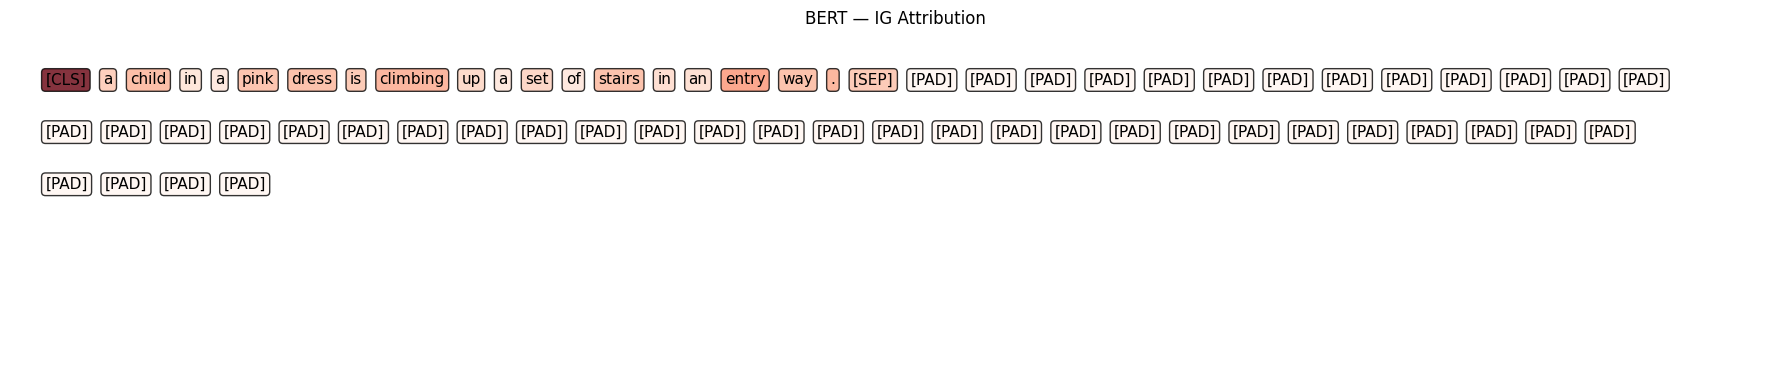

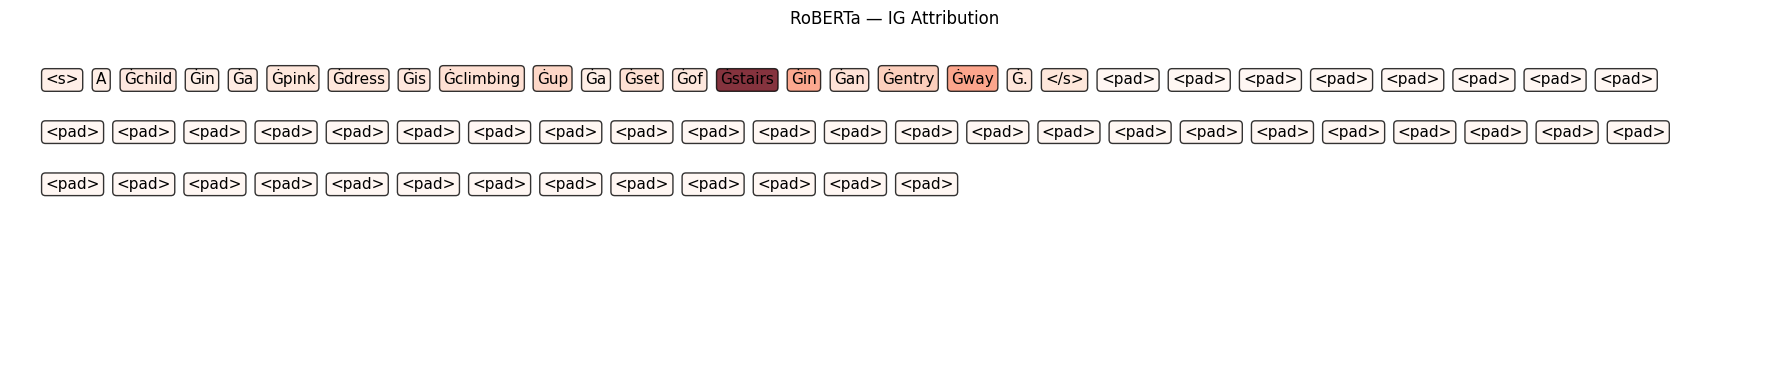

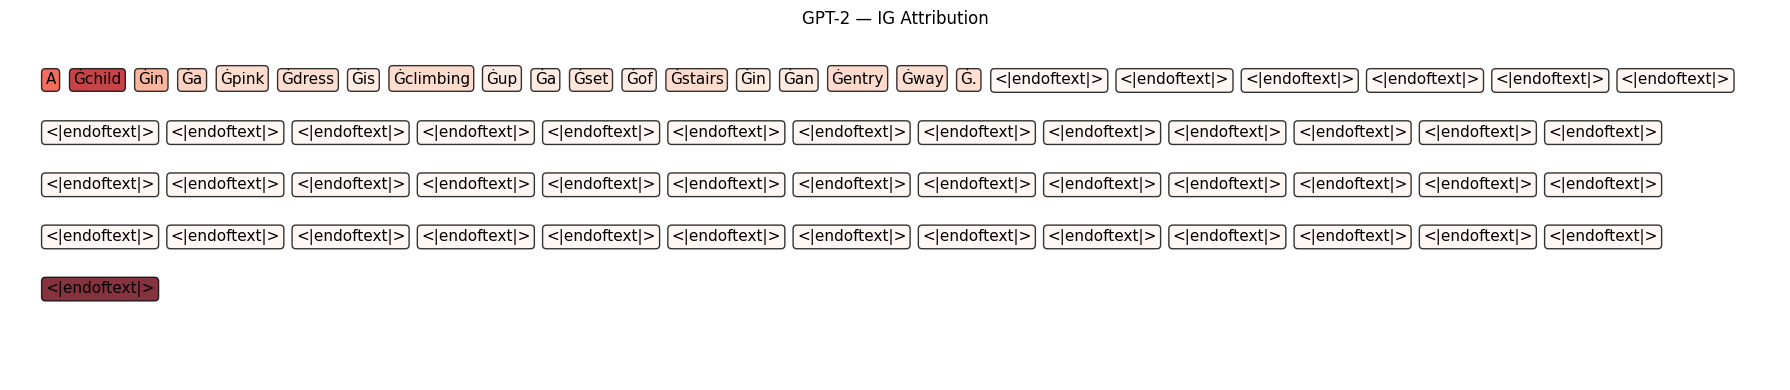

In [ ]:
# ============================================================
# TOKEN ATTRIBUTION VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# VISUALIZATION FUNCTION
# ------------------------------------------------------------

def visualize_tokens(
    tokenizer,
    input_ids,
    attributions,
    title="Token Attribution"
):

    tokens = tokenizer.convert_ids_to_tokens(
        input_ids.squeeze().tolist()
    )

    scores = attributions.squeeze().detach().cpu().numpy()

    scores = scores / (np.max(np.abs(scores)) + 1e-8)

    fig, ax = plt.subplots(figsize=(18, 4))

    ax.axis("off")

    x = 0.02
    y = 0.85

    for token, score in zip(tokens, scores):

        color = plt.cm.Reds(abs(score))

        text = ax.text(
            x,
            y,
            token,
            fontsize=11,
            transform=ax.transAxes,
            bbox=dict(
                facecolor=color,
                alpha=0.8,
                edgecolor="black",
                boxstyle="round,pad=0.25"
            )
        )

        renderer = fig.canvas.get_renderer()
        bb = text.get_window_extent(renderer=renderer)

        width = bb.width / fig.dpi / fig.get_size_inches()[0]

        x += width + 0.01

        # wrap line
        if x > 0.92:
            x = 0.02
            y -= 0.15

    plt.title(title)
    plt.tight_layout()
    plt.show()
    
    
def normalize_name(name):
    return (
        name.lower()
        .replace("-", "")
        .replace("_", "")
        .replace(" ", "")
    )

models_text_norm = {
    normalize_name(k): v
    for k, v in models_text.items()
}


for entry in all_attrs_text:

    model_name = entry["model"]

    _, tok, _ = models_text_norm[
        normalize_name(model_name)
    ]

    item = entry["attrs"][0]

    input_ids = item["input_ids"][0]
    attr = item["IG"][0]

    visualize_tokens(
        tok,
        input_ids,
        attr,
        title=f"{model_name} — IG Attribution"
    )
